In [1]:
import pandas as pd

df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
print("Shape:", df.shape)

# Check which columns have missing values (only show columns with at least 1 null)
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Shape: (2930, 82)
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


In [3]:
# Select a focused, meaningful set of features for predicting SalePrice
features = ['Gr Liv Area', 'Bedroom AbvGr', 'Full Bath', 'Overall Qual',
            'Overall Cond', 'Year Built', 'Total Bsmt SF', 'Garage Cars',
            'Lot Area', 'Neighborhood', 'SalePrice']

df_model = df[features].copy()

# Check nulls in our selected subset
print(df_model.isnull().sum())

df_model.head()

Gr Liv Area      0
Bedroom AbvGr    0
Full Bath        0
Overall Qual     0
Overall Cond     0
Year Built       0
Total Bsmt SF    1
Garage Cars      1
Lot Area         0
Neighborhood     0
SalePrice        0
dtype: int64


,Gr Liv Area,Bedroom AbvGr,Full Bath,Overall Qual,Overall Cond,Year Built,Total Bsmt SF,Garage Cars,Lot Area,Neighborhood,SalePrice
0,1656,3,1,6,5,1960,1080.0,2.0,31770,NAmes,215000
1,896,2,1,5,6,1961,882.0,1.0,11622,NAmes,105000
2,1329,3,1,6,6,1958,1329.0,1.0,14267,NAmes,172000
3,2110,3,2,7,5,1968,2110.0,2.0,11160,NAmes,244000
4,1629,3,2,5,5,1997,928.0,2.0,13830,Gilbert,189900


0


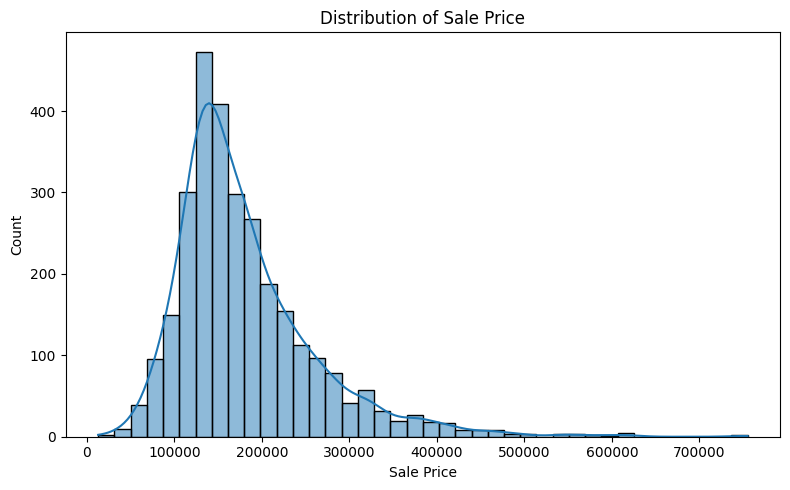

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [4]:
# Fill the 1-2 missing values with median (minimal impact either way)
df_model['Total Bsmt SF'] = df_model['Total Bsmt SF'].fillna(df_model['Total Bsmt SF'].median())
df_model['Garage Cars'] = df_model['Garage Cars'].fillna(df_model['Garage Cars'].median())

# Confirm no more nulls
print(df_model.isnull().sum().sum())

# Distribution of target variable (SalePrice)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_model['SalePrice'], kde=True, bins=40)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.tight_layout()
plt.show()

df_model['SalePrice'].describe()

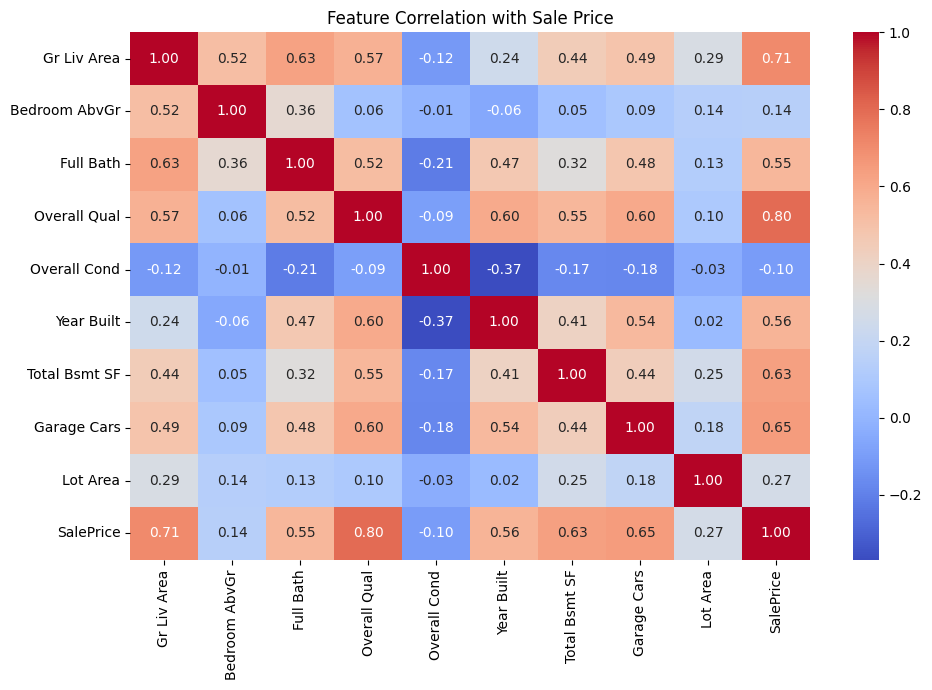

Shape after encoding: (2930, 37)


,Gr Liv Area,Bedroom AbvGr,Full Bath,Overall Qual,Overall Cond,Year Built,Total Bsmt SF,Garage Cars,Lot Area,SalePrice,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1656,3,1,6,5,1960,1080.0,2.0,31770,215000,...,False,False,False,False,False,False,False,False,False,False
1,896,2,1,5,6,1961,882.0,1.0,11622,105000,...,False,False,False,False,False,False,False,False,False,False
2,1329,3,1,6,6,1958,1329.0,1.0,14267,172000,...,False,False,False,False,False,False,False,False,False,False
3,2110,3,2,7,5,1968,2110.0,2.0,11160,244000,...,False,False,False,False,False,False,False,False,False,False
4,1629,3,2,5,5,1997,928.0,2.0,13830,189900,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# Correlation heatmap (numerical features only) vs SalePrice
numeric_features = ['Gr Liv Area', 'Bedroom AbvGr', 'Full Bath', 'Overall Qual',
                     'Overall Cond', 'Year Built', 'Total Bsmt SF', 'Garage Cars',
                     'Lot Area', 'SalePrice']

plt.figure(figsize=(10,7))
sns.heatmap(df_model[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Sale Price')
plt.tight_layout()
plt.show()

# One-Hot Encode the 'Neighborhood' categorical column
df_encoded = pd.get_dummies(df_model, columns=['Neighborhood'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separate features (X) and target (y)
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 1,237,444,680.75
RMSE: 35,177.33
R² Score: 0.8457


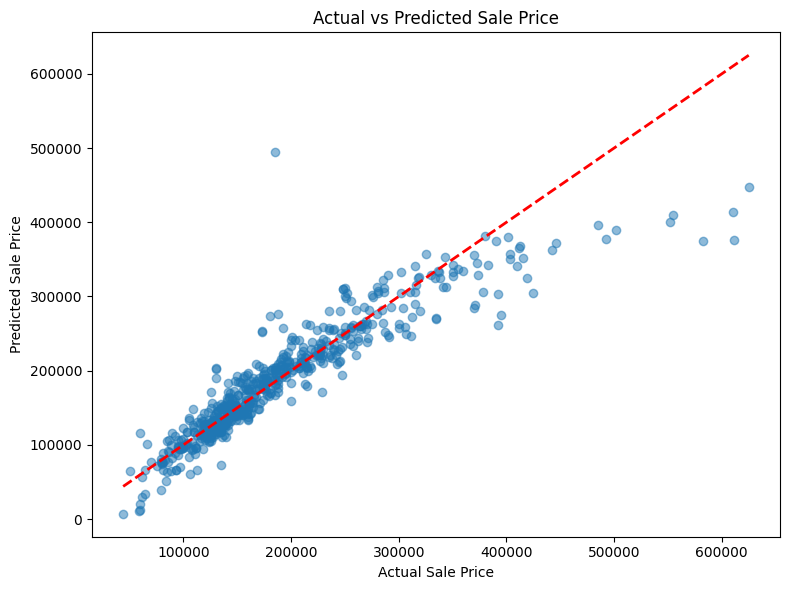

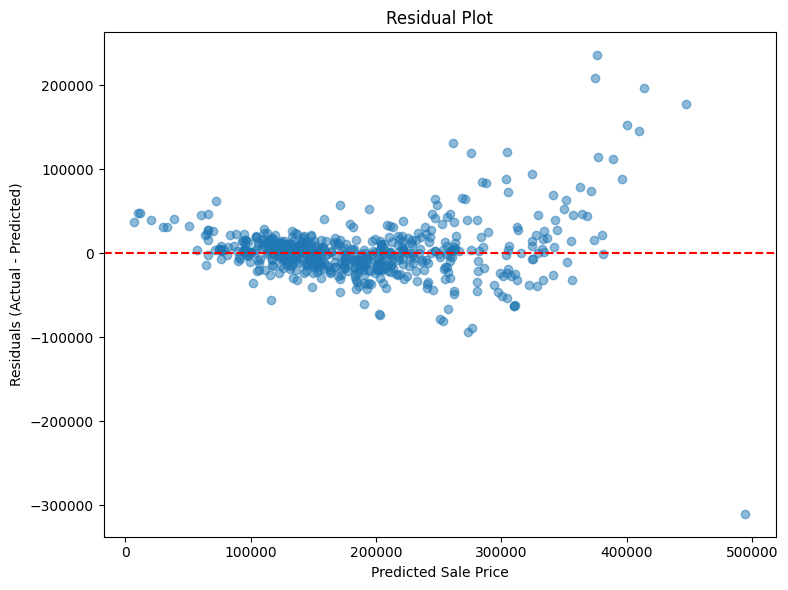

Top 10 Positive Impact Features:
                 Feature    Coefficient
18  Neighborhood_GrnHill  112414.656721
33  Neighborhood_StoneBr   77492.476175
27  Neighborhood_NridgHt   63430.780132
26  Neighborhood_NoRidge   63103.901536
14  Neighborhood_Crawfor   34846.256386
34   Neighborhood_Timber   25434.329026
35  Neighborhood_Veenker   25041.751795
32  Neighborhood_Somerst   23370.640064
12  Neighborhood_ClearCr   22718.233868
11  Neighborhood_BrkSide   17955.768353

Top 10 Negative Impact Features:
                 Feature   Coefficient
5             Year Built    471.813911
0            Gr Liv Area     56.069399
6          Total Bsmt SF     21.458412
8               Lot Area      0.695713
2              Full Bath  -2135.480293
24  Neighborhood_NPkVill  -4992.287582
1          Bedroom AbvGr  -6103.079598
20  Neighborhood_Landmrk  -6966.116671
10   Neighborhood_BrDale -10486.287555
9   Neighborhood_Blueste -16825.319784


In [7]:
# Scatter plot: Actual vs Predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.tight_layout()
plt.show()

# Residual plot (errors should be randomly scattered, no pattern)
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Coefficient analysis: which features impact price most?
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Top 10 Positive Impact Features:")
print(coefficients.head(10))

print("\nTop 10 Negative Impact Features:")
print(coefficients.tail(10))

### Model Performance & Interpretation

The Linear Regression model achieved an **R² score of 0.8457**, meaning it
explains ~84.6% of the variation in house sale prices using just 9 core
features plus neighborhood location. The RMSE of $35,177 indicates
predictions are typically within ~20% of the actual sale price.

**Key findings from coefficient analysis:**
- **Neighborhood is the single strongest price driver** — homes in GrnHill,
  StoneBr, and NridgHt neighborhoods command a $60K-$112K premium over the
  baseline neighborhood, confirming that location matters more than almost
  any physical feature of the house.
- **Year Built** has a modest positive effect (~$472/year), meaning newer
  homes are valued higher, holding other factors constant.
- **Bedroom count shows a slightly negative coefficient** once living area
  is already accounted for — likely because more bedrooms in a fixed square
  footage means smaller, less desirable rooms.
- The residual plot shows a reasonably random scatter around zero, though
  spread increases slightly for higher-priced homes, suggesting the model
  is slightly less precise for luxury properties.

## Conclusion

A Linear Regression model was built to predict house sale prices using key
structural features (living area, bedrooms, bathrooms, quality ratings,
basement size, garage capacity, lot area) combined with neighborhood
location data. The model achieved a strong R² of 0.8457, demonstrating that
these features capture the majority of price variation in the Ames housing
market. Neighborhood location emerged as the single most influential factor,
reinforcing that where a house is located often matters more than its
individual physical characteristics.